# Decay Comparison Across Tools

This notebook compares the attached decay-study outputs from BioDynaMo, Chaste, CompuTiX, and PhysiCell.

The workflow is intentionally split into small steps:
1. Load the result files into one common table using the whole-box average concentration.
2. Build a dense analytical solution and interpolate it onto each tool's time grid.
3. Compute the absolute error for every run and rank the runs within each tool.
4. Keep only the run with the smallest mean absolute error for each tool and compare those best runs directly.

In [36]:
from pathlib import Path

import xml.etree.ElementTree as ET



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import yaml

from pctk import multicellds

from scipy.interpolate import interp1d


## Step 1: Define Study Paths And Shared Physical Parameters

The four tools store their outputs in different formats, but they all represent the same decay setup.
For this comparison we use the average concentration over the full box because it is available for every attached tool result.

In [37]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')



BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'diffusion_decay_test'

CHASTE_DIR = ROOT / 'Chaste' / 'DiffusionNoCells'

COMPUTIX_DIR = ROOT / 'CompuTiX' / 'diffusion_single' / 'Decay'

PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'decay_study'



ANALYTICAL_PARAMETERS = {

    'box_length_um': 240.0,

    'diffusion_um2_per_min': 2000.0,

    'decay_rate_per_min': 1.0,

    'initial_concentration_uM': 10.0,

}



ANALYTICAL_PARAMETERS


{'box_length_um': 240.0,
 'diffusion_um2_per_min': 2000.0,
 'decay_rate_per_min': 1.0,
 'initial_concentration_uM': 10.0}

## Step 2: Use The Analytical Arrays From The Existing Notebook



The analytical reference values are copied directly from decay_study_decay.ipynb.

This keeps the comparison notebook simple while still using the same analytical data as the original decay-study notebook.


In [38]:
analytical_time_min = np.asarray([

    0.0, 0.52631579, 1.05263158, 1.57894737, 2.10526316, 2.63157895,

    3.15789474, 3.68421053, 4.21052632, 4.73684211, 5.26315789, 5.78947368,

    6.31578947, 6.84210526, 7.36842105, 7.89473684, 8.42105263, 8.94736842,

    9.47368421, 10.0,

])



analytical_average_uM = np.asarray([

    10.0, 7.79217467, 7.1711064, 6.96508102, 6.89482579, 6.87071343,

    6.86242517, 6.85957518, 6.8585951, 6.85825806, 6.85814215, 6.85810229,

    6.85808858, 6.85808387, 6.85808224, 6.85808169, 6.8580815, 6.85808143,

    6.85808141, 6.8580814,

])



def make_analytical_interpolator():

    interpolator = interp1d(

        analytical_time_min,

        analytical_average_uM,

        kind='linear',

        bounds_error=False,

        fill_value='extrapolate',

    )



    return analytical_time_min, analytical_average_uM, interpolator


## Step 3: Load Every Attached Result Into One Common Table



Each loader returns a table with the same columns: tool name, run identifier, time in minutes, spatial resolution in um, and average concentration in uM.



The metric used in every case is the whole-box average concentration.

BioDynaMo uses the average column from the text file, Chaste uses average_concentration(uM), CompuTiX uses c_domain, and PhysiCell computes the mean over all voxels in the microenvironment field.


In [39]:
def format_resolution_label(tool: str, dx_um: float, n_voxels_per_dim: int | None = None, dt_min: float | None = None) -> str:

    if tool in {'BioDynaMo', 'Chaste'}:

        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.0f} um'



    if tool == 'CompuTiX':

        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.2f} um, dt={dt_min:.1e} min'



    if tool == 'PhysiCell':

        return f'voxel size={dx_um:.0f} um'



    return f'dx={dx_um:.0f} um'





def load_biodynamo_runs() -> list[pd.DataFrame]:

    runs = []

    for csv_path in sorted(BIODYNAMO_DIR.glob('data_*.csv')):

        n_voxels_per_dim = int(csv_path.stem.split('_')[1])

        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_voxels_per_dim

        frame = pd.read_csv(csv_path, sep=r'\s+', header=None, names=['time_min', 'center_uM', 'average_uM'])

        run_id = f'BioDynaMo_N_{n_voxels_per_dim}'

        frame = frame.assign(

            tool='BioDynaMo',

            run_id=run_id,

            dx_um=dx_um,

            dt_min=np.nan,

            metric_type='whole-box average concentration',

            average_source='text file column 3: average_uM',

            resolution_label=format_resolution_label('BioDynaMo', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),

        )

        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'metric_type', 'average_source', 'resolution_label', 'time_min', 'average_uM']])

    return runs





def load_chaste_runs() -> list[pd.DataFrame]:

    runs = []

    for dat_path in sorted(CHASTE_DIR.glob('*.dat')):

        n_voxels_per_dim = int(dat_path.stem)

        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_voxels_per_dim

        frame = pd.read_csv(dat_path, sep=r'\s+')

        run_id = f'Chaste_N_{n_voxels_per_dim}'

        frame = frame.rename(columns={

            'time(minutes)': 'time_min',

            'average_concentration(uM)': 'average_uM',

        })

        frame = frame.assign(

            tool='Chaste',

            run_id=run_id,

            dx_um=dx_um,

            dt_min=np.nan,

            metric_type='whole-box average concentration',

            average_source='table column: average_concentration(uM)',

            resolution_label=format_resolution_label('Chaste', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),

        )

        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'metric_type', 'average_source', 'resolution_label', 'time_min', 'average_uM']])

    return runs





def load_computix_runs() -> list[pd.DataFrame]:

    runs = []

    for yaml_path in sorted(COMPUTIX_DIR.glob('dt-s-*_N-*.yaml')):

        data = yaml.safe_load(yaml_path.read_text())

        dx_um = float(data['dx']['values']) * 1e6

        dt_min = float(data['dt']['values']) / 60.0

        n_voxels_per_dim = int(data['N']['values'])

        frame = pd.DataFrame({

            'time_min': np.array(data['time_series']['values']['t']['values'], dtype=float) / 60.0,

            'average_uM': 1e3 * np.array(data['time_series']['values']['c_domain']['values'], dtype=float),

        })

        run_id = f'CompuTiX_N_{n_voxels_per_dim}_dt_{dt_min:.5g}min'

        frame = frame.assign(

            tool='CompuTiX',

            run_id=run_id,

            dx_um=dx_um,

            dt_min=dt_min,

            metric_type='whole-box average concentration',

            average_source='YAML time_series.values.c_domain.values',

            resolution_label=format_resolution_label('CompuTiX', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim, dt_min=dt_min),

        )

        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'metric_type', 'average_source', 'resolution_label', 'time_min', 'average_uM']])

    return runs





def load_physicell_runs() -> list[pd.DataFrame]:

    runs = []

    for folder in sorted(PHYSICELL_DIR.glob('size_*')):

        if folder.name.endswith('_uptake'):

            continue



        size_token = folder.name.split('_')[1]

        settings_path = folder / f'PhysiCell_settings_{size_token}.xml'

        dx_um = float(ET.parse(settings_path).getroot().findtext('.//domain/dx'))



        reader = multicellds.MultiCellDS(output_folder=str(folder))

        average_uM = []

        for _, microenvironment in reader.microenvironment_as_matrix_iterator():

            average_uM.append(microenvironment[4].mean() / 602.2)



        time_min = np.arange(len(average_uM), dtype=float) * 0.1

        run_id = f'PhysiCell_dx_{int(dx_um)}um'

        frame = pd.DataFrame({

            'time_min': time_min,

            'average_uM': np.array(average_uM, dtype=float),

            'tool': 'PhysiCell',

            'run_id': run_id,

            'dx_um': dx_um,

            'dt_min': np.nan,

            'metric_type': 'whole-box average concentration',

            'average_source': 'mean over all voxels from microenvironment[4]',

            'resolution_label': format_resolution_label('PhysiCell', dx_um=dx_um),

        })

        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'metric_type', 'average_source', 'resolution_label', 'time_min', 'average_uM']])

    return runs





all_runs = pd.concat(

    load_biodynamo_runs() + load_chaste_runs() + load_computix_runs() + load_physicell_runs(),

    ignore_index=True,

)



assert all_runs['metric_type'].eq('whole-box average concentration').all()

assert not all_runs['average_uM'].isna().any()



run_catalog = (

    all_runs[

        ['tool', 'run_id', 'dx_um', 'dt_min', 'metric_type', 'average_source', 'resolution_label']

    ]

    .drop_duplicates()

    .sort_values(['tool', 'dx_um', 'dt_min'])

)



run_catalog


,tool,run_id,dx_um,dt_min,metric_type,average_source,resolution_label
11000,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,whole-box average concentration,text file column 3: average_uM,"N=48 voxels/dim, dx=5 um"
1000,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,whole-box average concentration,text file column 3: average_uM,"N=24 voxels/dim, dx=10 um"
0,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,whole-box average concentration,text file column 3: average_uM,"N=12 voxels/dim, dx=20 um"
21000,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,whole-box average concentration,text file column 3: average_uM,"N=6 voxels/dim, dx=40 um"
24002,Chaste,Chaste_N_48,5.00000,NaN,whole-box average concentration,table column: average_concentration(uM),"N=48 voxels/dim, dx=5 um"
23001,Chaste,Chaste_N_24,10.00000,NaN,whole-box average concentration,table column: average_concentration(uM),"N=24 voxels/dim, dx=10 um"
22000,Chaste,Chaste_N_12,20.00000,NaN,whole-box average concentration,table column: average_concentration(uM),"N=12 voxels/dim, dx=20 um"
25003,Chaste,Chaste_N_6,40.00000,NaN,whole-box average concentration,table column: average_concentration(uM),"N=6 voxels/dim, dx=40 um"
26204,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,whole-box average concentration,YAML time_series.values.c_domain.values,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min"
26604,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,whole-box average concentration,YAML time_series.values.c_domain.values,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min"


## Step 4: Interpolate The Analytical Solution Onto Each Run

The analytical curve is evaluated on a dense time grid up to the largest observed simulation time, then linearly interpolated onto each tool's saved time points.

This produces one absolute-error time series per run.

In [40]:
max_time_min = float(all_runs['time_min'].max())

analytical_time_min, analytical_average_uM, analytical_interpolator = make_analytical_interpolator()



comparison = all_runs.copy()

comparison['analytical_uM'] = analytical_interpolator(comparison['time_min'].to_numpy())

comparison['abs_error_uM'] = (comparison['average_uM'] - comparison['analytical_uM']).abs()



run_metrics = (

    comparison.groupby(['tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)

    .agg(

        point_count=('time_min', 'size'),

        mean_absolute_error_uM=('abs_error_uM', 'mean'),

        max_absolute_error_uM=('abs_error_uM', 'max'),

        rmse_uM=('abs_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),

    )

    .reset_index()

    .sort_values(['tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])

)



run_metrics


,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM
3,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1000,2.147167,2.241171,2.169030
0,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",1000,3.205916,3.396630,3.254533
1,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",10000,3.560146,3.795667,3.620209
2,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",10000,3.699679,3.954392,3.764782
6,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",1001,0.187850,0.314283,0.190604
5,Chaste,Chaste_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",1001,0.364160,0.386768,0.369226
4,Chaste,Chaste_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",1001,0.706940,0.754533,0.721049
7,Chaste,Chaste_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1001,1.324828,1.407213,1.348827
13,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,0.209997,0.457830,0.214804
12,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100,0.214980,0.459420,0.219616


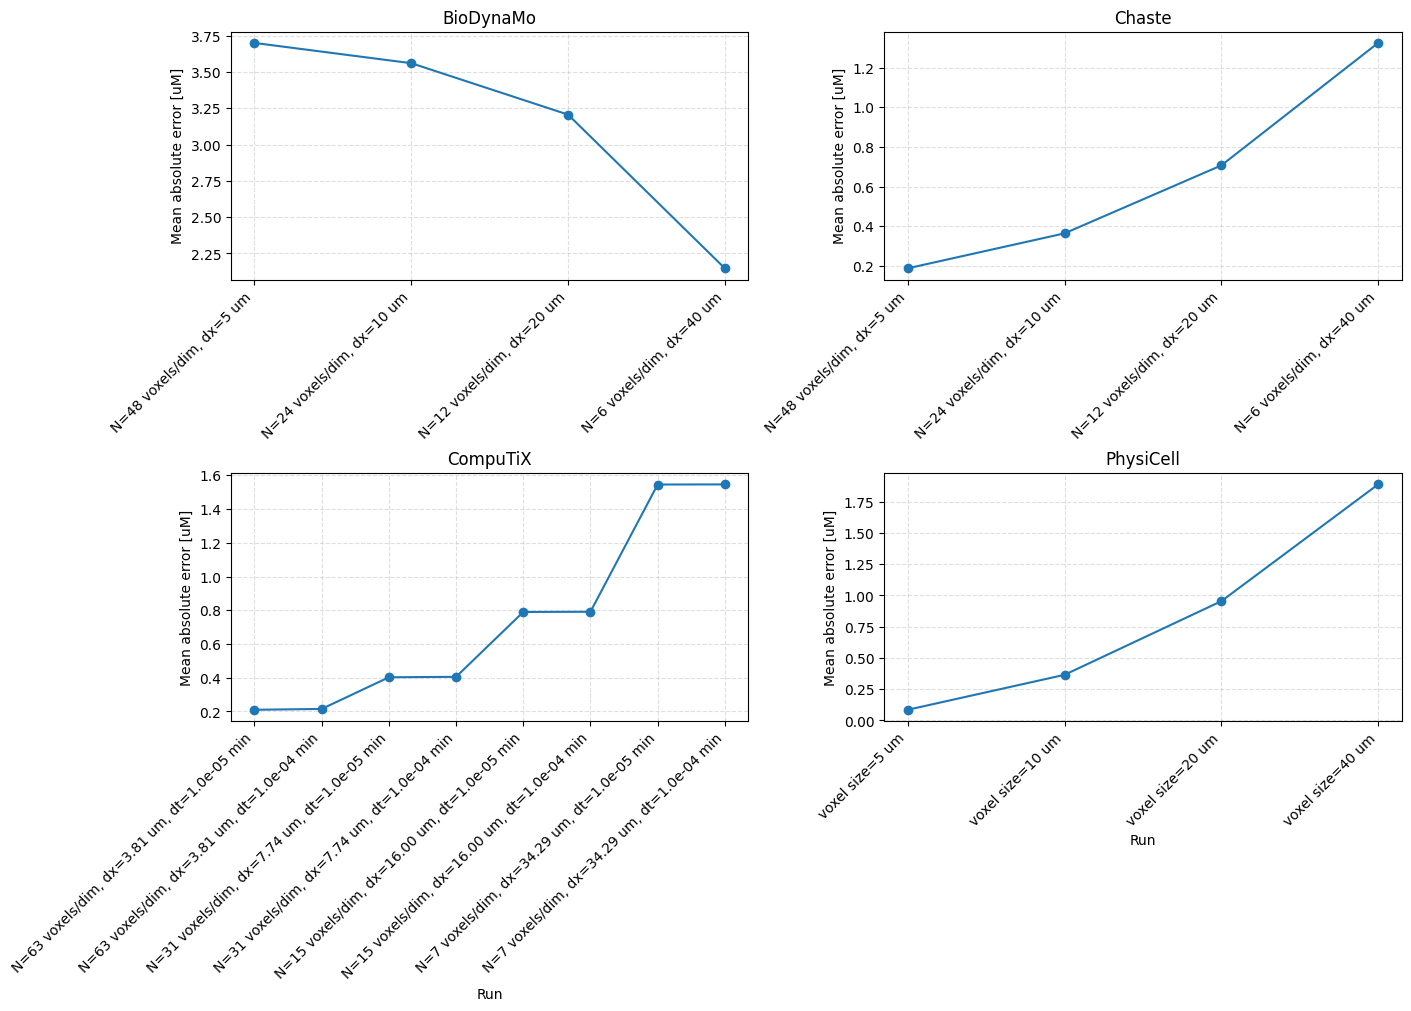

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.ravel()

for axis, tool_name in zip(axes, sorted(run_metrics['tool'].unique())):
    tool_metrics = run_metrics[run_metrics['tool'] == tool_name].copy()
    tool_metrics = tool_metrics.sort_values(['dx_um', 'dt_min'], na_position='last')

    axis.plot(range(len(tool_metrics)), tool_metrics['mean_absolute_error_uM'], marker='o')
    axis.set_title(tool_name)
    axis.set_ylabel('Mean absolute error [uM]')
    axis.set_xticks(range(len(tool_metrics)))
    axis.set_xticklabels(tool_metrics['resolution_label'], rotation=45, ha='right')
    axis.grid(True, linestyle='--', alpha=0.4)

axes[-2].set_xlabel('Run')
axes[-1].set_xlabel('Run')
plt.show()

## Step 5: Keep Only The Best Resolution Per Tool

Now we select the run with the smallest mean absolute error inside each tool family.
This is the step that answers which resolution is closest to the analytical solution for each tool.

In [42]:
best_runs = (
    run_metrics.sort_values(['tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
    .groupby('tool', as_index=False)
    .first()
    .sort_values('mean_absolute_error_uM')
)

best_runs

,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM
3,PhysiCell,PhysiCell_dx_5um,5.00000,NaN,voxel size=5 um,101,0.085254,0.392071,0.099625
1,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",1001,0.187850,0.314283,0.190604
2,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,0.209997,0.457830,0.214804
0,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1000,2.147167,2.241171,2.169030


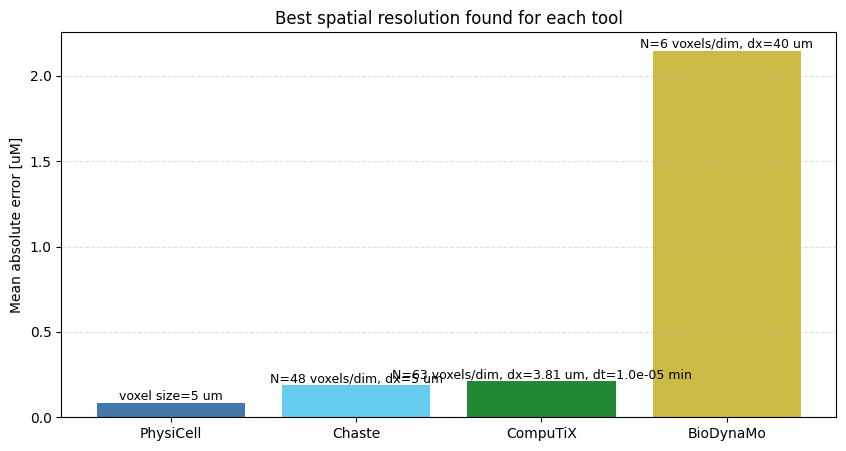

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(best_runs['tool'], best_runs['mean_absolute_error_uM'], color=['#4477aa', '#66ccee', '#228833', '#ccbb44'])

for bar, (_, row) in zip(bars, best_runs.iterrows()):
    label = row['resolution_label']
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        label,
        ha='center',
        va='bottom',
        rotation=0,
        fontsize=9,
    )

ax.set_ylabel('Mean absolute error [uM]')
ax.set_title('Best spatial resolution found for each tool')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.show()

## Step 6: Plot The Absolute Error Over Time For Only The Best Runs

This is the final comparison requested: one absolute-error curve per tool, but only for the run that stayed closest to the analytical solution.

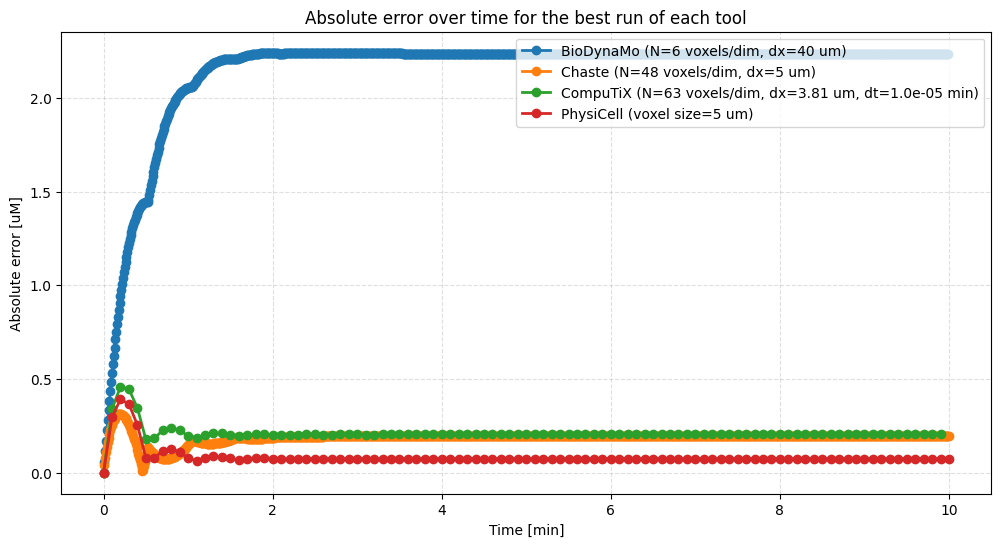

In [44]:
best_run_ids = best_runs['run_id'].tolist()

best_comparison = comparison[comparison['run_id'].isin(best_run_ids)].copy()



fig, ax = plt.subplots(figsize=(12, 6))



for tool_name, group in best_comparison.groupby('tool'):

    group = group.sort_values('time_min')

    label = f"{tool_name} ({group['resolution_label'].iloc[0]})"

    ax.plot(group['time_min'], group['abs_error_uM'], marker='o', linewidth=2, label=label)



ax.set_xlabel('Time [min]')

ax.set_ylabel('Absolute error [uM]')

ax.set_title('Absolute error over time for the best run of each tool')

ax.grid(True, linestyle='--', alpha=0.4)

ax.legend(loc='upper right')

plt.show()
